##  Parisagbp _Mini project2 _ Question3

# Part1

##  Imports





In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype

In [2]:
# https://drive.google.com/file/d/1JWWUiJ5rtdrnGEdfAcZSLBuTLxxvUIj6/view?usp=drive_link
!pip install --upgrade --no-cache-dir gdown
!gdown 1JWWUiJ5rtdrnGEdfAcZSLBuTLxxvUIj6


  Attempting uninstall: gdown
    Found existing installation: gdown 5.1.0
    Uninstalling gdown-5.1.0:
      Successfully uninstalled gdown-5.1.0
Downloading...
From: https://drive.google.com/uc?id=1JWWUiJ5rtdrnGEdfAcZSLBuTLxxvUIj6
To: /content/drug200.csv
100% 5.83k/5.83k [00:00<00:00, 12.7MB/s]


In [3]:
data = pd.read_csv('drug200.csv')
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [4]:
data = pd.read_csv('drug200.csv')
age = data['Age']
# age

#replacing labels
for i in range(200):
  if age[i] <= 40:
     age[i]= 'young'
  elif  40 < age[i] < 60:
    age[i] = 'adult'
  elif age[i] >= 60:
    age[i] = 'old'
#replacing in data
data['Age'] = age
# data


<ipython-input-4-758e6cf2911c>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age[i]= 'young'


In [5]:
# data = pd.read_csv('drug200.csv')
na = data['Na_to_K']
# between 6.27 & 38.2

#replacing labels
for i in range(200):
  if na[i] <=15:
     na[i]= 'Normal'
  elif na[i] > 15:
     na[i] = 'High'
#replacing in data
data['Na_to_K'] = na
data


<ipython-input-5-dd96903044d1>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  na[i] = 'High'


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,young,F,HIGH,HIGH,High,drugY
1,adult,M,LOW,HIGH,Normal,drugC
2,adult,M,LOW,HIGH,Normal,drugC
3,young,F,NORMAL,HIGH,Normal,drugX
4,old,F,LOW,HIGH,High,drugY
...,...,...,...,...,...,...
195,adult,F,LOW,HIGH,Normal,drugC
196,young,M,LOW,HIGH,Normal,drugC
197,adult,M,NORMAL,HIGH,Normal,drugX
198,young,M,NORMAL,NORMAL,Normal,drugX


## Test and train data

In [6]:
from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(data, test_size= 0.15)
data_train.shape, data_test.shape

((170, 6), (30, 6))

In [7]:
labels = data['Drug']
len(labels), labels.unique(), labels.value_counts()

(200,
 array(['drugY', 'drugC', 'drugX', 'drugA', 'drugB'], dtype=object),
 Drug
 drugY    91
 drugX    54
 drugA    23
 drugC    16
 drugB    16
 Name: count, dtype: int64)

In [8]:
labels = data_test['Drug']
len(labels), labels.unique(), labels.value_counts()

(30,
 array(['drugY', 'drugA', 'drugX', 'drugB', 'drugC'], dtype=object),
 Drug
 drugY    15
 drugX     7
 drugA     5
 drugB     2
 drugC     1
 Name: count, dtype: int64)

##  Entropy

\begin{align}
\text{Entropy}(Y) = -\sum_{i=1}^{C} p_i \log_2(p_i)
\end{align}

In [9]:
def entropy(labels):
    p = labels.value_counts() / len(labels)
    return -sum(p * np.log2(p))

In [10]:
entropy(data_train['Drug']),entropy(data_train['Sex']),entropy(data_train['BP']),entropy(data_train['Cholesterol']) ,entropy(data_train['Age']) ,entropy(data_train['Na_to_K'])

(1.9807253777879525,
 0.9999001572094884,
 1.574763015648164,
 0.9996006011927951,
 1.5358382069727337,
 0.9918977415529346)

## Information Gain

\begin{align}
\text{Information Gain}(\text{Feature}) = \text{Entropy}(\text{Parent}) - \sum_{\text{value} \in \text{Feature}} \frac{|\text{Subset with value}|}{|\text{Parent}|} \times \text{Entropy}(\text{Subset with value})
\end{align}

In [11]:
for value in data['BP'].unique():
 print(value)

HIGH
LOW
NORMAL


In [12]:
def information_gain(data, feature, target):
    # Entropy of parent
    entropy_parent = entropy(data[target])

    # Entropy of child
    entropy_child = 0
    for value in data[feature].unique():
        subset = data[data[feature] == value]
        wi = len(subset) / len(data)
        entropy_child += wi * entropy(subset[target])

    return entropy_parent - entropy_child

In [13]:
data_train.iloc[:, :-1].columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'], dtype='object')

In [14]:
[information_gain(data, feature, 'Drug') for feature in data.iloc[:, :-1].columns]

[0.13181944392177591,
 0.007703482714548349,
 0.6201266774024412,
 0.0931061958075754,
 0.994149171480893]

In [15]:
np.argmax([information_gain(data, feature, 'Drug') for feature in data.iloc[:, :-1].columns])

4

## Decision Tree

In [16]:
class Node:

    def __init__(self, feature=None, label=None):
        self.feature = feature
        self.label = label
        self.children = {}

    def __repr__(self):
        if self.feature is not None:
            return f'DecisionNode(feature="{self.feature}", children={self.children})'
        else:
            return f'LeafNode(label="{self.label}")'


In [17]:
data = data_train

In [18]:
def make_tree(data, target):
    # leaf node?
    if len(data[target].unique()) == 1:
        return Node(label=data[target].iloc[0])

    features = data.drop(target, axis=1).columns
    if len(features) == 0 or len(data) == 0:
        return Node(label=data[target].mode()[0])

    # calculate information gain
    gains = [information_gain(data, feature, target) for feature in features]

    # greedy search to find best feature
    max_gain_idx = np.argmax(gains)
    best_feature = features[max_gain_idx]

    # make a node
    node = Node(feature=best_feature)

    # loop over the best feature
    for value in data[best_feature].unique():
        subset = data[data[best_feature] == value].drop(best_feature, axis=1)
        # display(subset)

        node.children[value] = make_tree(subset, target)

    return node

tree = make_tree(data, 'Drug')

In [19]:
tree = make_tree(data, 'Drug')
tree

DecisionNode(feature="Na_to_K", children={'Normal': DecisionNode(feature="BP", children={'HIGH': DecisionNode(feature="Age", children={'adult': DecisionNode(feature="Sex", children={'M': DecisionNode(feature="Cholesterol", children={'NORMAL': LeafNode(label="drugA"), 'HIGH': LeafNode(label="drugA")}), 'F': DecisionNode(feature="Cholesterol", children={'NORMAL': LeafNode(label="drugB"), 'HIGH': LeafNode(label="drugA")})}), 'old': LeafNode(label="drugB"), 'young': LeafNode(label="drugA")}), 'NORMAL': LeafNode(label="drugX"), 'LOW': DecisionNode(feature="Cholesterol", children={'HIGH': LeafNode(label="drugC"), 'NORMAL': LeafNode(label="drugX")})}), 'High': LeafNode(label="drugY")})

In [20]:
tree.feature

'Na_to_K'

In [21]:
from graphviz import Digraph, nohtml

g = Digraph('g', filename='decision-tree.gv', node_attr={'shape': 'record', 'height': '.1'})

def plot_tree(tree, g):
    root_node = tree.feature
    if root_node is None:
        return g
    g.node(root_node, nohtml(root_node))
    child_nodes = tree.children.keys()

    for i, child in enumerate(child_nodes):
        node = tree.children[child]
        name = node.feature if node.feature is not None else child+node.label
        label = node.feature if node.feature is not None else node.label
        g.node(name, nohtml(label))
        g.edge(root_node, name, label=child)
        plot_tree(node, g)
    return g

g = plot_tree(tree, g)
g.render('decision_tree', format='png', view=True)

'decision_tree.png'

## Evaluation

In [22]:
data_test

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
184,young,F,HIGH,HIGH,High,drugY
140,adult,M,HIGH,NORMAL,Normal,drugA
103,adult,M,NORMAL,HIGH,Normal,drugX
177,young,M,NORMAL,HIGH,High,drugY
8,old,M,NORMAL,HIGH,High,drugY
71,young,F,NORMAL,HIGH,High,drugY
171,adult,M,LOW,NORMAL,Normal,drugX
185,adult,F,NORMAL,NORMAL,High,drugY
66,young,M,HIGH,HIGH,Normal,drugA
169,young,F,HIGH,HIGH,Normal,drugA


In [23]:
def predict(node, sample):
    if node.feature is None:
        return node.label

    feature_value = sample[node.feature]

    if feature_value in node.children:
        return predict(node.children[feature_value], sample)
    else:
        return node.label

[predict(tree, sample) for _, sample in data_test.iterrows()]

['drugY',
 'drugA',
 'drugX',
 'drugY',
 'drugY',
 'drugY',
 'drugX',
 'drugY',
 'drugA',
 'drugA',
 'drugX',
 'drugX',
 'drugY',
 'drugB',
 'drugB',
 'drugY',
 'drugY',
 'drugX',
 'drugY',
 'drugY',
 'drugY',
 'drugA',
 'drugY',
 'drugA',
 'drugY',
 'drugY',
 'drugX',
 'drugY',
 'drugC',
 'drugX']

In [24]:
predicted = [predict(tree, sample) for _, sample in data_test.iterrows()]
T= data_test['Drug']
actual = T.reset_index(drop=True)

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (2).

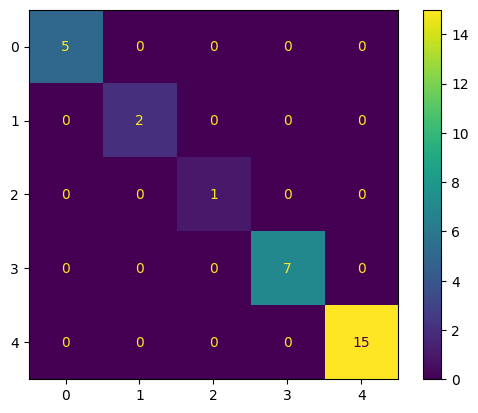

In [27]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
import matplotlib.pyplot as plt

cm_display.plot()
plt.show

In [26]:
s= 0
for i in range(30):
  if actual[i] == predicted[i]:
    s = s + 1
  else:
    s = s + 0

print(s)

30


# Part2


## DecisionTreeClassifier

In [28]:
data = pd.read_csv('drug200.csv')
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [ ]:
data = pd.read_csv('drug200.csv')
#sex
sex = data['Sex']
#replacing labels
for i in range(200):
  if sex[i] == 'M':
     sex[i]= 0
  else:
     sex[i] = 1

data['Sex'] = sex

#BP
bp = data['BP']
#replacing labels
for i in range(200):
  if bp[i] == 'LOW':
     bp[i]= 0
  elif bp[i] == 'NORMAL':
     bp[i] = 1
  else:
     bp[i] = 2
data['BP'] = bp

#CH
ch = data['Cholesterol']

for i in range(200):
  if ch[i] == 'NORMAL':
     ch[i]= 0
  else:
     ch[i] = 1

data['Cholesterol'] = ch




In [30]:
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,2,1,25.355,drugY
1,47,0,0,1,13.093,drugC
2,47,0,0,1,10.114,drugC
3,28,1,1,1,7.798,drugX
4,61,1,0,1,18.043,drugY
...,...,...,...,...,...,...
195,56,1,0,1,11.567,drugC
196,16,0,0,1,12.006,drugC
197,52,0,1,1,9.894,drugX
198,23,0,1,0,14.020,drugX


In [31]:
from sklearn.model_selection import train_test_split

X = data.drop('Drug', axis=1)
y = data['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=64)

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(random_state=64)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 0.98


## confusion_matrix

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (2).

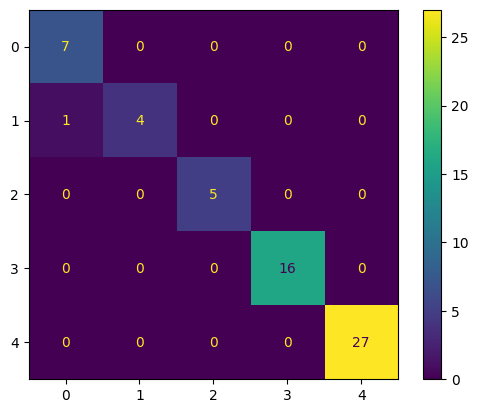

In [33]:
from sklearn import metrics
confusion_matrix = metrics.confusion_matrix(y_test, y_pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
import matplotlib.pyplot as plt

cm_display.plot()
plt.show

##  Hyperparameter

max depth

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')


Accuracy: 0.98
Precision: 0.99
Recall: 0.98


In [53]:
# max_depth
depths = [2, 3, 4, 8]
for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=64)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Max Depth: {depth}, Accuracy: {accuracy:.2f}')

Max Depth: 2, Accuracy: 0.83
Max Depth: 3, Accuracy: 0.90
Max Depth: 4, Accuracy: 0.98
Max Depth: 8, Accuracy: 0.98


min samples split

In [57]:
# min_samples_split
splits = [2, 10, 20, 100]
for split in splits:
    clf = DecisionTreeClassifier(min_samples_split=split, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Min Samples Split: {split}, Accuracy: {accuracy:.2f}')


Min Samples Split: 2, Accuracy: 0.98
Min Samples Split: 10, Accuracy: 0.98
Min Samples Split: 20, Accuracy: 0.98
Min Samples Split: 100, Accuracy: 0.72


# Part3


In [62]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')


Accuracy: 0.98
Precision: 0.99
Recall: 0.98


AdaBoostClassifier

In [61]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# base with low depth
base = DecisionTreeClassifier(max_depth=None, random_state=64)

ada_clf = AdaBoostClassifier(base_estimator=base, n_estimators=50, random_state=64)
ada_clf.fit(X_train, y_train)

y_pred = ada_clf.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f'AdaBoost - Accuracy: {accuracy:.2f}')
print(f'AdaBoost - Precision: {precision:.2f}')
print(f'AdaBoost - Recall: {recall:.2f}')


AdaBoost - Accuracy: 0.98
AdaBoost - Precision: 0.99
AdaBoost - Recall: 0.98


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


RandomForestClassifier

In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

rf_clf = RandomForestClassifier(max_depth=8, random_state=64)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print(f'RandomForest - Accuracy: {accuracy:.2f}')
print(f'RandomForest - Precision: {precision:.2f}')
print(f'RandomForest - Recall: {recall:.2f}')


RandomForest - Accuracy: 0.98
RandomForest - Precision: 0.99
RandomForest - Recall: 0.98
